# 03 — Modelagem


In [20]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd


RANDOM_STATE = 42

RAW = Path("..") / "data" / "raw" / "dataset_tratado.csv"          # PREENCHER: nome do arquivo
PROCESSED = Path("..") / "data" / "processed"
TARGET = "TARGET"
GRUPO = "PROFILE_ID"                                        

pd.set_option("display.max_columns", None)

In [21]:
df = pd.read_csv(PROCESSED / "dataset_tratado.csv")
print("Shape:", df.shape)
print(f"Perfis distintos (grupos): {df[GRUPO].nunique()}")
print(f"Maus pagadores (TARGET=1): {df[TARGET].sum()} de {len(df)} ({df[TARGET].mean() * 100:.2f}%)")

Shape: (36457, 21)
Perfis distintos (grupos): 9728
Maus pagadores (TARGET=1): 616 de 36457 (1.69%)


## 1. Split treino/teste


In [22]:
from sklearn.model_selection import StratifiedGroupKFold
import pandas as pd

# ID é identificador, não preditor
X = df.drop(columns=["ID", GRUPO, TARGET])
y = df[TARGET]

# Grupo usado para impedir que o mesmo grupo fique em treino e validação
grupos = df[GRUPO]

skf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)
for fold, (train_idx, test_idx) in enumerate(
    skf.split(X, y, groups=grupos), start=1
):
    
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    print(f"\nFold {fold}")
    
    print(
        pd.DataFrame(
            {
                "linhas": [len(X_train), len(X_test)],
                "positivos": [int(y_train.sum()), int(y_test.sum())],
                "pct_positivos": [
                    round(y_train.mean() * 100, 2),
                    round(y_test.mean() * 100, 2)
                ],
            },
            index=["treino", "teste"]
        )
    )


Fold 1
        linhas  positivos  pct_positivos
treino   29165        492           1.69
teste     7292        124           1.70

Fold 2
        linhas  positivos  pct_positivos
treino   29167        493           1.69
teste     7290        123           1.69

Fold 3
        linhas  positivos  pct_positivos
treino   29165        493           1.69
teste     7292        123           1.69

Fold 4
        linhas  positivos  pct_positivos
treino   29165        493           1.69
teste     7292        123           1.69

Fold 5
        linhas  positivos  pct_positivos
treino   29166        493           1.69
teste     7291        123           1.69


## 2. Modelos candidatos


In [23]:
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

colunas_num = X.select_dtypes("number").columns.tolist()
colunas_cat = X.select_dtypes(exclude="number").columns.tolist()

# Para Regressão Logística
def pre_processador_logistica():

    return ColumnTransformer([

        ("num", StandardScaler(), colunas_num),

        ("cat", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ), colunas_cat),
    ])
# Para modelos baseados em árvores
def pre_processador_arvores():

    return ColumnTransformer([

        ("num", "passthrough", colunas_num),

        ("cat", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ), colunas_cat),
    ])
modelos = {
    # Baseline
    "dummy_baseline": Pipeline([

        ("clf", DummyClassifier(strategy="prior")),
    ]),
    # Regressão Logística → precisa/beneficia-se da padronização
    "logistic_regression": Pipeline([

        ("prep", pre_processador_logistica()),

        ("clf", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        )),
    ]),
    # Random Forest → não precisa de StandardScaler
    "random_forest": Pipeline([

        ("prep", pre_processador_arvores()),

        ("clf", RandomForestClassifier(
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )),
    ]),
    # XGBoost → não precisa de StandardScaler
    "xgboost": Pipeline([
        ("prep", pre_processador_arvores()),
        ("clf", XGBClassifier(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.2,
            subsample=0.8,
            colsample_bytree=0.6,
            eval_metric="aucpr",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )),
    ]),

}


**Pré-processamento (diferenciado por família de modelos).** As variáveis categóricas passam por `OneHotEncoder` em todos os modelos. Já as variáveis numéricas passam por `StandardScaler` apenas na Regressão Logística, enquanto nos modelos baseados em árvores são mantidas em sua escala original (`passthrough`). Padronizar é necessário para a regressão logística (renda vai de dezenas de milhares a mais de um milhão; filhos vai de 0 a 19), mas desnecessário para algoritmos baseados em decisão por limiares (árvores).

**Os modelos.**

* **DummyClassifier (baseline):** ignora as variáveis e dá a todos os clientes o mesmo score (a taxa de positivos do treino). Não aprende nada, e por isso é a régua mínima: um modelo que não o supere não tem utilidade. Seu ROC-AUC é sempre 0,5 e seu PR-AUC é a prevalência.
* **Regressão logística:** simples e fácil de explicar; funciona como referência. Passa pelo pré-processamento com padronização das numéricas.
* **Random Forest:** combinação de várias árvores de decisão treinadas em paralelo. No código, utiliza os parâmetros padrão do algoritmo, sem limitação explícita de profundidade ou de tamanho mínimo das folhas.
* **XGBoost:** algoritmo de *gradient boosting* que constrói árvores em sequência, onde cada uma corrige os erros das anteriores. Utiliza 300 estimadores, profundidade máxima de 5 (`max_depth=5`), taxa de aprendizado de 0,2 (`learning_rate=0.2`) e subamostragem de linhas e colunas (`subsample=0.8`, `colsample_bytree=0.6`).

**Desbalanceamento (1 positivo para 42 negativos).** Na Regressão Logística e no Random Forest, o parâmetro `class_weight="balanced"` ajusta automaticamente os pesos das classes de forma inversamente proporcional à sua frequência. Isso faz cada mau pagador pesar cerca de 42 vezes mais no treino, evitando que o modelo aprenda a apostar sempre na classe majoritária. 
**Hiperparâmetros fixos, sem busca:** valores razoáveis e definidos manualmente, sem etapa de otimização (*grid search* ou *random search*).


## 3. Validação cruzada

Esquema de validação cruzada em 5 etapas que garante um teste honesto e realista do modelo ao combinar duas proteções essenciais: a estratificação, que preserva a proporção exata de maus e bons pagadores em todas as divisões de treino e teste, e o agrupamento por perfil, que impede que registros do mesmo cliente (como as duplicatas com o mesmo PROFILE_ID) sejam divididos entre treino e teste, evitando o vazamento de dados (data leakage) e garantindo métricas de avaliação confiáveis.

Métricas:

- **ROC-AUC (principal):** qualidade do ordenamento dos clientes, sem depender de corte. 0,5 é o acaso.
- **PR-AUC:** foca na classe rara; o acaso vale a prevalência (**0,017**), então o ganho é fácil de ler.
- **Recall:** depende do corte padrão de 0,5; serve só como complemento.

In [24]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, precision_score

# Validação cruzada estratificada por grupo
cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Métricas com o tratamento para zero_division na precisão
metricas = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "precision": make_scorer(precision_score, zero_division=0),  # Trata a divisão por zero
    "recall": "recall",
    "acuracia": "accuracy",
    "f1": "f1"
}

# Avaliação dos modelos
linhas = []
for nome, modelo in modelos.items():
    r = cross_validate(
        modelo,
        X,
        y,
        groups=grupos,
        cv=cv,
        scoring=metricas,
        n_jobs=-1
    )
    linhas.append({
        "modelo": nome,
        "roc_auc": r["test_roc_auc"].mean(),
        "roc_auc_desvio": r["test_roc_auc"].std(),
        "pr_auc": r["test_pr_auc"].mean(),
        "pr_auc_desvio": r["test_pr_auc"].std(),
        "precision": r["test_precision"].mean(),
        "recall": r["test_recall"].mean(),
        "f1": r["test_f1"].mean(),
        "acuracia": r["test_acuracia"].mean()
    })

# Tabela final
comparacao = (
    pd.DataFrame(linhas)
    .set_index("modelo")
    .sort_values("pr_auc", ascending=False)
    .round(3)
)

print(
    f"Referência do acaso -> "
    f"ROC-AUC: 0.500 | "
    f"PR-AUC: {y.mean():.3f} (prevalência)"
)

comparacao

Referência do acaso -> ROC-AUC: 0.500 | PR-AUC: 0.017 (prevalência)


,roc_auc,roc_auc_desvio,pr_auc,pr_auc_desvio,precision,recall,f1,acuracia
modelo,,,,,,,,
xgboost,0.621,0.017,0.106,0.028,0.747,0.047,0.088,0.984
random_forest,0.589,0.024,0.041,0.007,0.150,0.066,0.089,0.977
logistic_regression,0.549,0.017,0.026,0.003,0.019,0.446,0.036,0.602
dummy_baseline,0.500,0.000,0.017,0.000,0.000,0.000,0.000,0.983


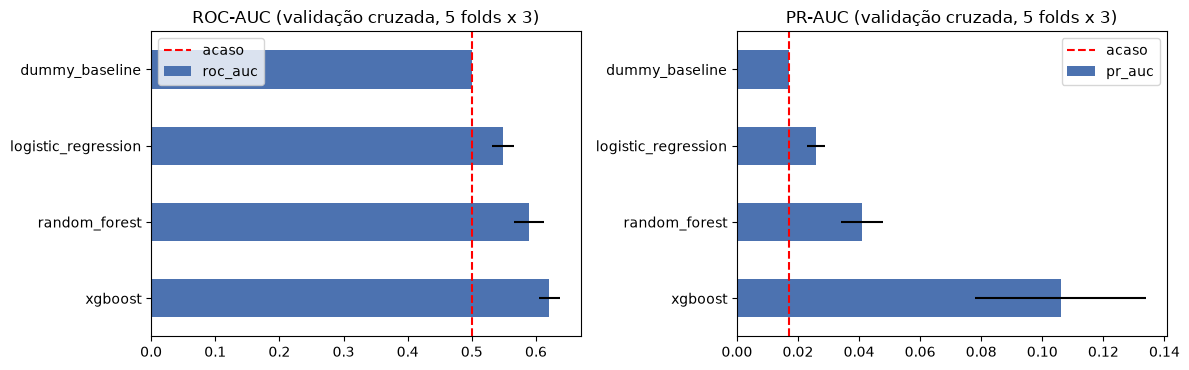

In [25]:
fig, eixos = plt.subplots(1, 2, figsize=(12, 3.8))
for ax, metrica, acaso, titulo in [
    (eixos[0], "roc_auc", 0.5, "ROC-AUC"),
    (eixos[1], "pr_auc", y_train.mean(), "PR-AUC"),
]:
    comparacao[metrica].plot(kind="barh", xerr=comparacao[f"{metrica}_desvio"], color="#4C72B0", ax=ax)
    ax.axvline(acaso, color="red", ls="--", label="acaso")
    ax.set_title(f"{titulo} (validação cruzada, 5 folds x 3)")
    ax.set_ylabel("")
    ax.legend()
plt.tight_layout()
plt.show()

A análise visual dos gráficos consolida as métricas numéricas anteriores e revela um detalhe crucial sobre a estabilidade dos modelos.

* **Superioridade Média do XGBoost:** O modelo XGBoost apresenta as maiores barras azuis em ambos os gráficos, confirmando que possui o maior poder preditivo médio.


* **ROC-AUC (Gráfico da Esquerda):** O XGBoost destaca-se claramente acima da linha de acaso ($0,50$) e dos demais modelos. A linha preta curta sobre a barra indica que esse desempenho de ordenação geral é consistente e estável entre as diferentes rodadas da validação cruzada.


* **PR-AUC e o Desbalanceamento (Gráfico da Direita):** A linha vermelha pontilhada (acaso) está colada no eixo zero, o que ilustra perfeitamente a extrema raridade dos maus pagadores na base de dados. O XGBoost e o Random Forest conseguem se descolar bem dessa linha, ao contrário da regressão logística.


* **Alerta Crítico de Instabilidade:** A revelação mais importante da imagem é a **extensa barra de erro (linha preta) no PR-AUC do XGBoost**. Essa grande amplitude significa que o modelo sofre de alta variância na captura da classe minoritária. Dependendo de como os dados foram divididos nos *folds* de teste, o desempenho do XGBoost oscilou violentamente.

## 4. Comparação

| Modelo              |   ROC-AUC |    Desvio |    PR-AUC | Recall |  Acurácia | F1-Score |
| ------------------- | --------: | --------: | --------: | -----: | --------: | -------: |
| dummy_baseline      |     0.500 |     0.000 |     0.017 |  0.000 |     0.983 |    0.000 |
| logistic_regression |     0.549 |     0.017 |     0.026 |  0.446 |     0.602 |    0.036 |
| random_forest       |     0.589 |     0.024 |     0.041 |  0.066 |     0.977 |    0.089 |
| xgboost             | **0.621** | **0.017** | **0.106** |  0.047 | **0.984** |    0.088 |




* **O Problema Central:** A base de dados apresenta um severo desbalanceamento de classes, com a classe positiva representando apenas ~1,7% dos registros. Nessa condição, a **Acurácia é uma métrica enganosa** (o modelo *dummy_baseline* atinge 98,3% de acurácia apenas chutando a classe majoritária).

* A **Regressão Logística** captura mais inadimplentes ($Recall = 44,6\%$) por usar pesos balanceados, mas seu poder de separação geral é fraco ($ROC-AUC = 0,549$).

**O Melhor Modelo em Desempenho Global (XGBoost):**
* O **XGBoost** lidera o ranqueamento geral, obtendo o maior **ROC-AUC ($0,621$)** e o maior **PR-AUC ($0,106$)**.

* Seu PR-AUC é **mais de 6 vezes superior ao da baseline ($0,017$)**, provando que ele possui a melhor capacidade técnica de ordenar os clientes por probabilidade de risco.

* **O Gargalo no Limiar Padrão ($0,50$):**
* No ponto de corte original de 0,5, tanto o XGBoost quanto o Random Forest apresentam um **Recall extremamente baixo** ($4,7\%$ e $6,6\%$, respectivamente), deixando passar a quase totalidade dos inadimplentes.


